In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor, LGBMClassifier
import sys
import re
from sklearn.preprocessing import LabelEncoder

In [61]:
df_sold = pd.read_csv("../data/Sold/sold_transactions.csv")
df_sold.head()

C:\Users\mayab\AppData\Local\Temp\ipykernel_32972\4086709524.py:1: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: WaterfrontYN, 3: ListAgentEmail, 4: OriginatingSystemName, 5: OriginatingSystemSubName, 6: BuyerAgencyCompensationType, 7: latfilled, 8: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.read_csv("../data/Sold/sold_transactions.csv")


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,Year,year_month,rate_30yr_fixed
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN,2024,2024-01,6.6425
1,HighDesert,HighDesert,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,...,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,2024,2024-01,6.6425
2,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,...,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,2024,2024-01,6.6425
3,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,...,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,2024,2024-01,6.6425
4,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,...,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,2024,2024-01,6.6425


##### Number of Rows and Columns

In [62]:
df_sold.shape

(591115, 87)

The the sold transactions file has 591115 rows and 87 columns.

##### Review column data types

In [63]:
df_sold.info()

<class 'pandas.DataFrame'>
RangeIndex: 591115 entries, 0 to 591114
Data columns (total 87 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 519608 non-null  str    
 1   ListAgentAOR                  523069 non-null  str    
 2   Flooring                      347464 non-null  str    
 3   ViewYN                        531925 non-null  object 
 4   WaterfrontYN                  322 non-null     object 
 5   BasementYN                    9738 non-null    object 
 6   PoolPrivateYN                 516977 non-null  object 
 7   OriginalListPrice             589404 non-null  float64
 8   ListingKey                    591115 non-null  int64  
 9   ListAgentEmail                547714 non-null  str    
 10  CloseDate                     591115 non-null  str    
 11  ClosePrice                    591108 non-null  float64
 12  ListAgentFirstName            587682 non-null  str    


#### **Missing Value Analysis**

##### Calculate missing counts and percentages per column

In [64]:
missing_sold_counts = df_sold.isnull().sum()
missing_sold_counts

BuyerAgentAOR       71507
ListAgentAOR        68046
Flooring           243651
ViewYN              59190
WaterfrontYN       590793
                    ...  
latfilled          495322
lonfilled          495322
Year                    0
year_month              0
rate_30yr_fixed         0
Length: 87, dtype: int64

In [65]:
missing_sold_percent = (df_sold.isnull().mean()) * 100
missing_sold_percent

BuyerAgentAOR      12.096969
ListAgentAOR       11.511466
Flooring           41.218883
ViewYN             10.013280
WaterfrontYN       99.945527
                     ...    
latfilled          83.794524
lonfilled          83.794524
Year                0.000000
year_month          0.000000
rate_30yr_fixed     0.000000
Length: 87, dtype: float64

In [66]:
missing_summary = pd.DataFrame({
    "missing_sold_counts": missing_sold_counts,
    "missing_sold_percent": missing_sold_percent
})

In [67]:
missing_sold_summary = missing_summary.sort_values(by="missing_sold_percent", ascending=False)
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                 100.0
AboveGradeFinishedArea                     591115                 100.0
MiddleOrJuniorSchoolDistrict               591115                 100.0
ElementarySchoolDistrict                   591115                 100.0
FireplacesTotal                            591115                 100.0
...                                           ...                   ...
MlsStatus                                       0                   0.0
StateOrProvince                                 0                   0.0
Year                                            0                   0.0
year_month                                      0                   0.0
rate_30yr_fixed                                 0                   0.0

[87 rows x 2 columns]


In [68]:
missing_sold_summary = missing_sold_summary[missing_sold_summary["missing_sold_counts"] > 0]
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115            100.000000
AboveGradeFinishedArea                     591115            100.000000
MiddleOrJuniorSchoolDistrict               591115            100.000000
ElementarySchoolDistrict                   591115            100.000000
FireplacesTotal                            591115            100.000000
...                                           ...                   ...
PostalCode                                    165              0.027913
ListAgentFullName                             161              0.027237
ListingContractDate                            83              0.014041
ListAgentLastName                              61              0.010319
ClosePrice                                      7              0.001184

[74 rows x 2 columns]


In [69]:
missing_sold_summary["missing_sold_percent"] = missing_sold_summary["missing_sold_percent"].round(2)
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                100.00
AboveGradeFinishedArea                     591115                100.00
MiddleOrJuniorSchoolDistrict               591115                100.00
ElementarySchoolDistrict                   591115                100.00
FireplacesTotal                            591115                100.00
...                                           ...                   ...
PostalCode                                    165                  0.03
ListAgentFullName                             161                  0.03
ListingContractDate                            83                  0.01
ListAgentLastName                              61                  0.01
ClosePrice                                      7                  0.00

[74 rows x 2 columns]


In [70]:
missing_above_90 = missing_sold_summary[missing_sold_summary['missing_sold_percent'] > 90]
print(missing_above_90)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                100.00
AboveGradeFinishedArea                     591115                100.00
MiddleOrJuniorSchoolDistrict               591115                100.00
ElementarySchoolDistrict                   591115                100.00
FireplacesTotal                            591115                100.00
WaterfrontYN                               590793                 99.95
TaxYear                                    590748                 99.94
BusinessType                               589483                 99.72
TaxAnnualAmount                            588608                 99.58
BelowGradeFinishedArea                     588525                 99.56
BasementYN                                 581377                 98.35
BuilderName                                568536                 96.18
LotSizeDimensions                          560102               

Dropping Variables:
- CoveredSpaces                              
- AboveGradeFinishedArea                     
- MiddleOrJuniorSchoolDistrict               
- ElementarySchoolDistrict                   
- FireplacesTotal                            
- WaterfrontYN                               
- TaxYear                                   
- BusinessType                               
- TaxAnnualAmount                            
- BelowGradeFinishedArea                     
- BasementYN                                 
- BuilderName                                
- LotSizeDimensions                          
- CoBuyerAgentFirstName 

In [71]:
missing_above_70 = missing_sold_summary[missing_sold_summary['missing_sold_percent'] > 70]
print(missing_above_70)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                100.00
AboveGradeFinishedArea                     591115                100.00
MiddleOrJuniorSchoolDistrict               591115                100.00
ElementarySchoolDistrict                   591115                100.00
FireplacesTotal                            591115                100.00
WaterfrontYN                               590793                 99.95
TaxYear                                    590748                 99.94
BusinessType                               589483                 99.72
TaxAnnualAmount                            588608                 99.58
BelowGradeFinishedArea                     588525                 99.56
BasementYN                                 581377                 98.35
BuilderName                                568536                 96.18
LotSizeDimensions                          560102               

In [72]:
missing_above_70.shape

(28, 2)

In [73]:
missing_above_70

,missing_sold_counts,missing_sold_percent
CoveredSpaces,591115,100.00
AboveGradeFinishedArea,591115,100.00
MiddleOrJuniorSchoolDistrict,591115,100.00
ElementarySchoolDistrict,591115,100.00
FireplacesTotal,591115,100.00
WaterfrontYN,590793,99.95
TaxYear,590748,99.94
BusinessType,589483,99.72
TaxAnnualAmount,588608,99.58
BelowGradeFinishedArea,588525,99.56


To perserve the variables, it would be sufficient if each variable contain less than 70% of missing values in order to use imputation to replace the missingness in the data. 

So, variables with 70% of missing variables will be removed from the dataset because through imputation with variables with a significant number of missingness, it may contribute to bias towards certain values than others. 

In [74]:
df_sold_clean = df_sold.drop(columns=['CoveredSpaces',
'AboveGradeFinishedArea',	
'MiddleOrJuniorSchoolDistrict',
'ElementarySchoolDistrict',
'FireplacesTotal',
'WaterfrontYN',
'TaxYear',
'BusinessType',
'TaxAnnualAmount',	
'BelowGradeFinishedArea',
'BasementYN',	
'BuilderName',	
'LotSizeDimensions',	
'CoBuyerAgentFirstName',	
'OriginatingSystemName',	
'OriginatingSystemSubName',	
'ElementarySchool',	
'MiddleOrJuniorSchool',	
'BuyerAgencyCompensationType',
'BuyerAgencyCompensation',	
'BuildingAreaTotal',	
'HighSchool',	
'latfilled',	
'lonfilled',	
'CoListAgentFirstName',	
'CoListAgentLastName',
'CoListOfficeName',
'AssociationFeeFrequency'	])

In [75]:
df_sold_clean.shape

(591115, 59)

In [76]:
# Calculate percentage for all columns
missing_pct = (df_sold_clean.isna().sum() / len(df_sold_clean)) * 100

# Filter to show only columns that actually have missing data
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

SubdivisionName             64.720232
MainLevelBedrooms           46.942981
Flooring                    41.218883
HighSchoolDistrict          33.351209
AssociationFee              30.998029
AttachedGarageYN            27.720833
Stories                     20.017256
Levels                      13.749778
GarageSpaces                12.801401
PoolPrivateYN               12.542060
BuyerAgentAOR               12.096969
NewConstructionYN           11.869433
ListAgentAOR                11.511466
MLSAreaMajor                10.996507
ViewYN                      10.013280
LotSizeAcres                 9.467532
LotSizeSquareFeet            9.228830
LotSizeArea                  9.151519
FireplaceYN                  8.741108
PropertySubType              7.667205
ListAgentEmail               7.342226
LivingArea                   7.058694
BedroomsTotal                6.658434
BathroomsTotalInteger        4.635477
BuyerOfficeAOR               4.311005
YearBuilt                    4.214747
Latitude    

In [77]:
num_cols_with_missing = df_sold_clean.isna().any().sum()

print(f"Number of variables with missing values: {num_cols_with_missing}")

Number of variables with missing values: 46


In [78]:
cols_rows_dropping = missing_pct[(missing_pct < 1) & (missing_pct > 0)]
cols_rows_dropping

OriginalListPrice           0.289453
ClosePrice                  0.001184
ListAgentFirstName          0.580767
ListAgentLastName           0.010319
UnparsedAddress             0.152255
ListPrice                   0.153946
ListAgentFullName           0.027237
BuyerAgentMlsId             0.309584
BuyerAgentFirstName         0.443907
BuyerAgentLastName          0.056842
StreetNumberNumeric         0.247329
City                        0.074436
ContractStatusChangeDate    0.120450
ListingContractDate         0.014041
PostalCode                  0.027913
dtype: float64

In [79]:
cols_rows_dropped = ['OriginalListPrice', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'ListPrice', 'ListAgentFullName', 'BuyerAgentMlsId',
                'BuyerAgentFirstName', 'BuyerAgentLastName', 'StreetNumberNumeric', 'City', 'ContractStatusChangeDate', 'ListingContractDate', 'PostalCode']

In [80]:
df_sold_cleaned = df_sold_clean.dropna(subset=['OriginalListPrice', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'ListPrice', 'ListAgentFullName', 'BuyerAgentMlsId',
                'BuyerAgentFirstName', 'BuyerAgentLastName', 'StreetNumberNumeric', 'City', 'ContractStatusChangeDate', 'ListingContractDate', 'PostalCode'])

In [81]:
df_sold_cleaned.shape

(579463, 59)

In [82]:
df_sold_clean.shape[0] - df_sold_cleaned.shape[0]

11652

In [83]:
# Calculate percentage for all columns
missing_pct = (df_sold_cleaned.isna().sum() / len(df_sold_cleaned)) * 100

# Filter to show only columns that actually have missing data
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

SubdivisionName          64.446910
MainLevelBedrooms        46.157218
Flooring                 41.177435
HighSchoolDistrict       33.361750
AssociationFee           30.451125
AttachedGarageYN         27.695470
Stories                  19.041078
Levels                   12.705039
GarageSpaces             12.635837
BuyerAgentAOR            12.081013
NewConstructionYN        11.651477
PoolPrivateYN            11.572611
ListAgentAOR             11.501166
MLSAreaMajor             10.944098
ViewYN                    9.802351
LotSizeAcres              9.409401
LotSizeSquareFeet         9.169179
LotSizeArea               9.093937
FireplaceYN               8.496832
PropertySubType           7.567179
ListAgentEmail            7.346630
LivingArea                6.842197
BedroomsTotal             6.409037
BathroomsTotalInteger     4.531609
BuyerOfficeAOR            4.184046
YearBuilt                 4.114844
ParkingTotal              2.967230
Latitude                  2.955668
Longitude           

In [84]:
# Create a reference mapping of Names -> Emails
# Drop any rows that have missing emails so the map is 'clean'
email_lookup = df_sold_cleaned.dropna(subset=['ListAgentEmail']).drop_duplicates(['ListAgentFirstName', 'ListAgentLastName'])

# Set the names as the index to make the 'lookup' possible
email_lookup = email_lookup.set_index(['ListAgentFirstName', 'ListAgentLastName'])['ListAgentEmail']

# Create a function to apply the logic
def fill_missing_emails(row):
    # Only try to fill if the current email is missing
    if pd.isna(row['ListAgentEmail']):
        # Look up the name in our reference map
        return email_lookup.get((row['ListAgentFirstName'], row['ListAgentLastName']), "None")
    return row['ListAgentEmail']

# Apply it to the dataframe
df_sold_cleaned['ListAgentEmail'] = df_sold_cleaned.apply(fill_missing_emails, axis=1)

In [85]:
df_sold_cleaned['ListAgentEmail'].isna().sum()

np.int64(0)

In [86]:
(df_sold_cleaned['ListAgentEmail'] == 'None').sum()

np.int64(2537)

From the code above, I noticed that there are no missing values for list agent's first and last names, so to determine their emails, I tried to look up any matches by full name to get the list agent's emails for the rows that are missing them. If there are no matches, those emails will be preserved by having a value of "None" (i.e. no email provided).

Source: https://medium.com/@adedokunjuliusayobami/handling-missing-values-with-light-gbm-4a222d8af31b

Light Gradient Boosting Machine (LightGBM) is a tree-based ensemble learning approach to enhance efficiency and scalability on high-dimensional feature set and large-scale dataset. It builds multiple decision trees sequentially to minimize loss and improve predictive performance. It hadnles missing values by learning the best split direction for missing entries at each node. We are basically training the model to predict the missing values by using other features as predictors, as would in a normal regression/classification problem. 

In [87]:
categorical_columns = new_df.select_dtypes(include=['object']).columns
continuous_columns = new_df.select_dtypes(include=['int64', 'float64']).columns

C:\Users\mayab\AppData\Local\Temp\ipykernel_32972\1767474806.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = new_df.select_dtypes(include=['object']).columns


Determine the categorical variables with not too many unique values. 

In [88]:
high_card_cols = df_sold_cleaned[categorical_columns].nunique()
high_card_cols = high_card_cols[high_card_cols > 300]
print(high_card_cols)

Flooring                       341
ListAgentEmail               91512
CloseDate                      821
ListAgentFirstName           17101
ListAgentLastName            37797
UnparsedAddress             541925
ListOfficeName               21335
BuyerOfficeName              23982
ListAgentFullName            87169
BuyerAgentMlsId             133402
BuyerAgentFirstName          20773
BuyerAgentLastName           43293
MLSAreaMajor                  1124
SubdivisionName              19585
ListingId                   578926
City                          1231
ContractStatusChangeDate       821
PurchaseContractDate          1223
ListingContractDate           1793
HighSchoolDistrict             447
PostalCode                    4044
dtype: int64


In [89]:
df_sold_cleaned[categorical_columns].isna().sum()

BuyerAgentAOR                70005
ListAgentAOR                 66645
Flooring                    238608
ViewYN                       56801
PoolPrivateYN                67059
ListAgentEmail                   0
CloseDate                        0
ListAgentFirstName               0
ListAgentLastName                0
UnparsedAddress                  0
PropertyType                     0
ListOfficeName                   0
BuyerOfficeName               6566
ListAgentFullName                0
BuyerAgentMlsId                  0
BuyerAgentFirstName              0
BuyerAgentLastName               0
MLSAreaMajor                 63417
CountyOrParish                   0
MlsStatus                        0
AttachedGarageYN            160485
PropertySubType              43849
SubdivisionName             373446
BuyerOfficeAOR               24245
ListingId                        0
City                             0
ContractStatusChangeDate         0
PurchaseContractDate         11725
ListingContractDate 

Flooring, BuyerOfficeName, MLSAreaMajor, SubdivisionName, PurchaseContractDate, and HighSchoolDistrict have more than 300 unique categorical values, making them computationally tiring to impute with LightGBM. 

In [90]:
df_sold_cleaned.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR',
       'YearBuilt', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces

In [91]:
reduced_categorical_columns = ['BuyerAgentAOR', 'ListAgentAOR', 'ViewYN', 'PoolPrivateYN', 'AttachedGarageYN',
                               'PropertySubType', 'BuyerOfficeAOR', 'FireplaceYN', 'Levels', 'NewConstructionYN']

In [92]:
df_sold_cleaned['BuyerAgentAOR'].value_counts().head()

BuyerAgentAOR
OrangeCounty             50652
PacificWest              34318
BeverlyHillsGreaterLa    33937
Southland                32833
SanDiego                 31529
Name: count, dtype: int64

In [93]:
df_sold_cleaned['ListAgentAOR'].value_counts().head()

ListAgentAOR
OrangeCounty             51071
PacificWest              34555
BeverlyHillsGreaterLa    33985
Southland                33490
SanDiego                 31586
Name: count, dtype: int64

In [94]:
df_sold_cleaned['ViewYN'].value_counts().head()


ViewYN
True     319220
False    203442
Name: count, dtype: int64

In [95]:
df_sold_cleaned['PoolPrivateYN'].value_counts().head()

PoolPrivateYN
False    452224
True      60180
Name: count, dtype: int64

In [96]:
df_sold_cleaned['AttachedGarageYN'].value_counts().head()

AttachedGarageYN
True     326625
False     92353
Name: count, dtype: int64

In [97]:
df_sold_cleaned['PropertySubType'].value_counts().head()

PropertySubType
SingleFamilyResidence    354546
Condominium              101507
Townhouse                 33517
Apartment                 13203
Duplex                    11024
Name: count, dtype: int64

In [98]:
df_sold_cleaned['BuyerOfficeAOR'].value_counts().head()

BuyerOfficeAOR
OrangeCounty    53207
PacificWest     37909
SanDiego        35619
Southland       33373
Mlslistings     24683
Name: count, dtype: int64

In [99]:
df_sold_cleaned['FireplaceYN'].value_counts().head()

FireplaceYN
True     325236
False    204991
Name: count, dtype: int64

In [100]:
df_sold_cleaned['Levels'].value_counts().head()

Levels
One            295089
Two            169943
ThreeOrMore     24622
MultiSplit      11554
One,Two          1602
Name: count, dtype: int64

In [101]:
df_sold_cleaned['NewConstructionYN'].value_counts().head()

NewConstructionYN
False    491306
True      20641
Name: count, dtype: int64

------------------------

In [111]:
reduced_categorical_columns

['BuyerAgentAOR',
 'ListAgentAOR',
 'ViewYN',
 'PoolPrivateYN',
 'AttachedGarageYN',
 'PropertySubType',
 'BuyerOfficeAOR',
 'FireplaceYN',
 'Levels',
 'NewConstructionYN']

In [144]:
def impute_numeric_lgbm(df, num_cols, non_negative_cols=None):
    df = df.copy()

    if non_negative_cols is None:
        non_negative_cols = []

    for col in num_cols:
        mask = df[col].isna()
        if not mask.any():
            continue

        X = df.drop(columns=[col]).copy()
        y = df.loc[~mask, col]

        # Encode categoricals safely
        for c in X.select_dtypes(include=['object', 'category']).columns:
            X[c] = X[c].astype('category').cat.codes.astype(float)

        X_train = X.loc[~mask]
        X_test = X.loc[mask]

        model = LGBMRegressor(
            n_estimators=100,
            random_state=42,
            verbosity=-1
        )

        model.fit(X_train, y)
        preds = model.predict(X_test)

        # enforce real-world constraints explicitly
        if col in non_negative_cols:
            preds = np.clip(preds, 0, None)

        df.loc[mask, col] = preds

    return df

In [145]:
def impute_categorical_lgbm(df, cat_cols):
    df = df.copy()

    for col in cat_cols:
        mask = df[col].isna()
        if not mask.any():
            continue

        y = df.loc[~mask, col]

        le = LabelEncoder()
        y_enc = le.fit_transform(y)

        X = df.drop(columns=[col]).copy()

        # Encode categoricals
        for c in X.select_dtypes(include=['object', 'category']).columns:
            X[c] = X[c].astype('category').cat.codes

        X_train = X.loc[~mask]
        X_test = X.loc[mask]

        model = LGBMClassifier(
            n_estimators=100,
            random_state=42,
            verbosity=-1,
            class_weight='balanced'
        )

        model.fit(X_train, y_enc)

        preds = model.predict(X_test)
        df.loc[mask, col] = le.inverse_transform(preds)

    return df

In [146]:
new_df = df_sold_cleaned.copy()

In [147]:
df_imputed = df_sold_cleaned.copy()

In [148]:
df_imputed = impute_numeric_lgbm(
    df_imputed,
    continuous_columns
)

C:\Users\mayab\AppData\Local\Temp\ipykernel_32972\3482043353.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in X.select_dtypes(include=['object', 'category']).columns:
C:\Users\mayab\AppData\Local\Temp\ipykernel_32972\3482043353.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/doc

In [149]:
df_imputed = impute_categorical_lgbm(
    df_imputed,
    reduced_categorical_columns
)

C:\Users\mayab\AppData\Local\Temp\ipykernel_32972\2094811554.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in X.select_dtypes(include=['object', 'category']).columns:
C:\Users\mayab\AppData\Local\Temp\ipykernel_32972\2094811554.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/doc

In [150]:
df_imputed.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,2.226584,False,1.000000,Other,94401,6472.000000,1.020867e+08,2024,2024-01,6.6425
1,HighDesert,HighDesert,NaN,True,False,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,0.092065,False,125.457608,NaN,92394,-21.259968,5.232000e+04,2024,2024-01,6.6425
2,OrangeCounty,OrangeCounty,NaN,True,False,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,1.046258,False,4.301166,NaN,93240,10.756271,2.173640e+05,2024,2024-01,6.6425
3,InlandValleys,InlandValleys,NaN,True,False,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,0.974562,False,6.356953,NaN,92308,215.135641,2.178000e+05,2024,2024-01,6.6425
4,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,True,False,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,1.085406,False,1.124679,NaN,93544,0.000000,1.088830e+05,2024,2024-01,6.6425


In [151]:
# Total missing values
print("Total NaNs:", df_imputed.isna().sum().sum())

# Per-column missing
print(df_imputed.isna().sum().sort_values(ascending=False))

# Summary stats comparison
print(df_sold_cleaned.describe())
print(df_imputed.describe())

Total NaNs: 887081
SubdivisionName             373446
Flooring                    238608
HighSchoolDistrict          193319
MLSAreaMajor                 63417
PurchaseContractDate         11725
BuyerOfficeName               6566
ViewYN                           0
ListAgentEmail                   0
PoolPrivateYN                    0
OriginalListPrice                0
ListingKey                       0
ListAgentFirstName               0
ClosePrice                       0
ListAgentLastName                0
Latitude                         0
PropertyType                     0
LivingArea                       0
Longitude                        0
UnparsedAddress                  0
DaysOnMarket                     0
ListPrice                        0
ListAgentFullName                0
ListOfficeName                   0
BuyerAgentMlsId                  0
CloseDate                        0
BuyerAgentAOR                    0
ListAgentAOR                     0
ListingKeyNumeric                0
B

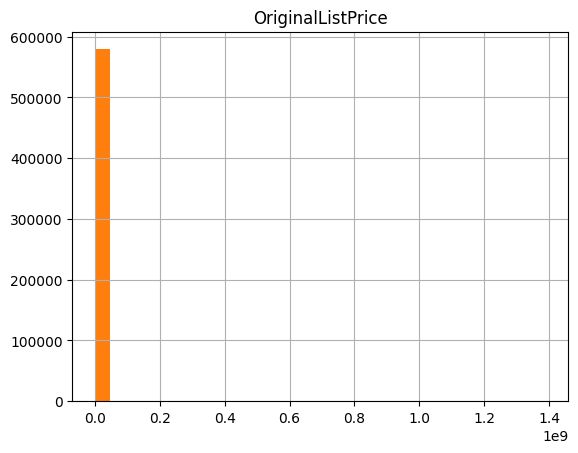

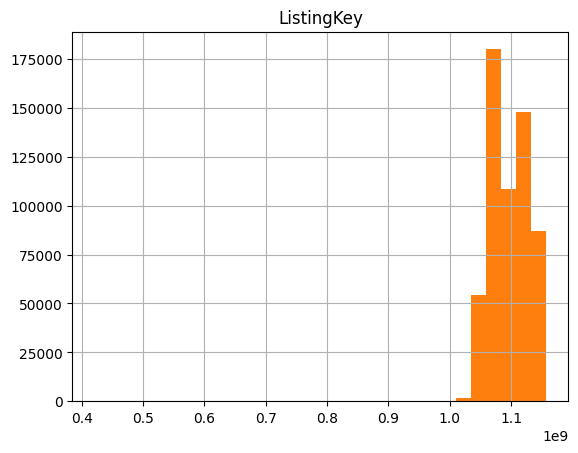

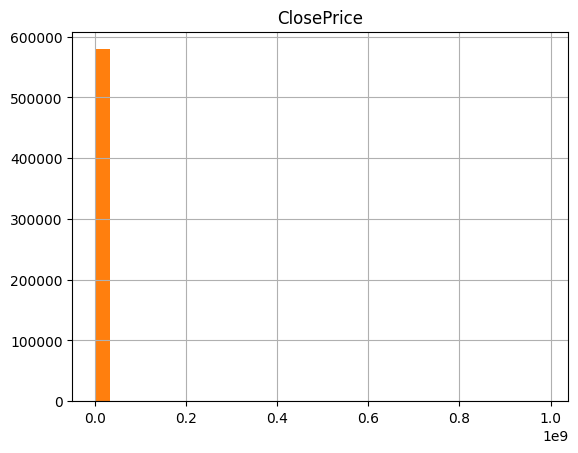

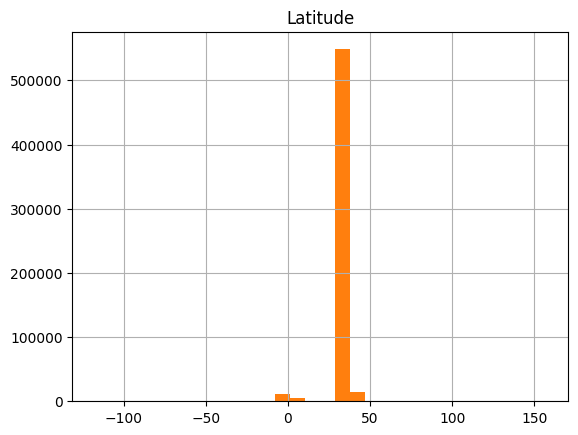

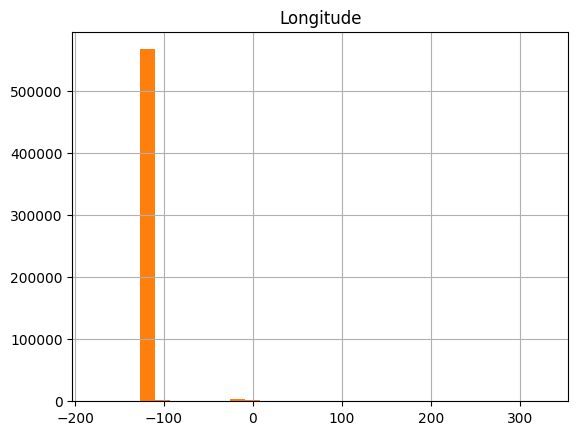

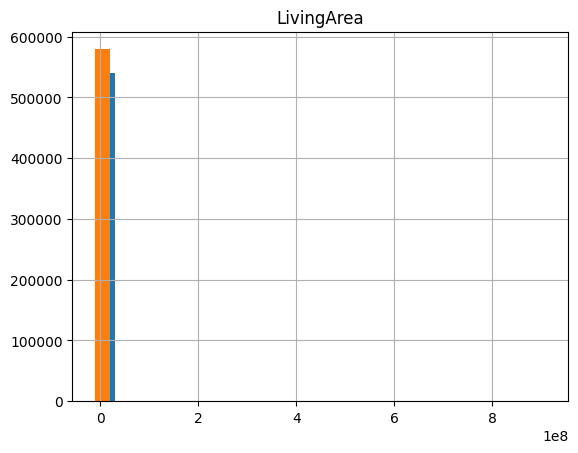

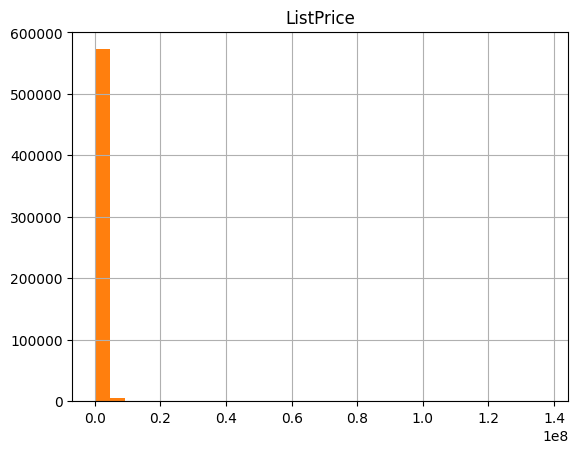

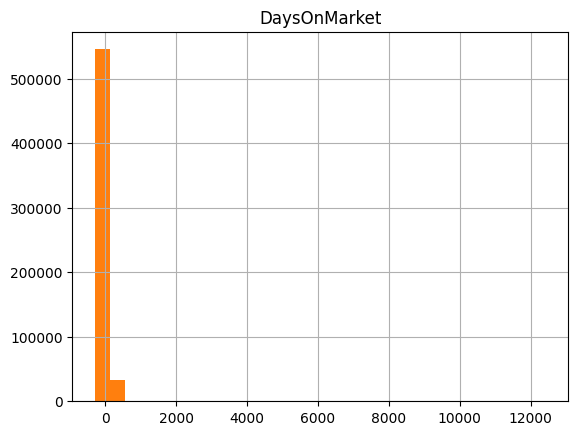

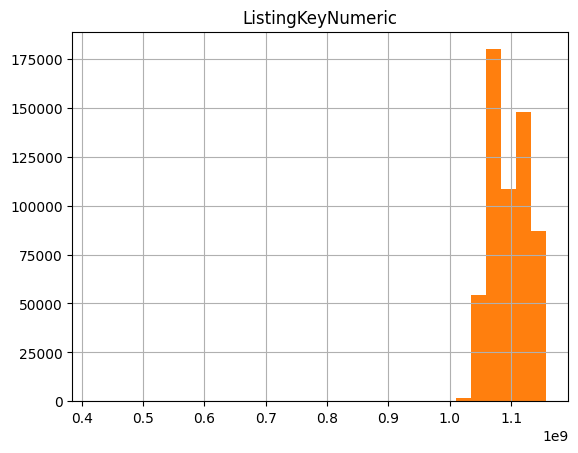

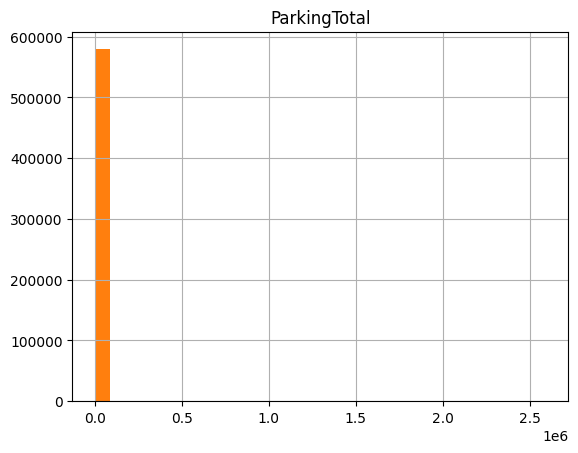

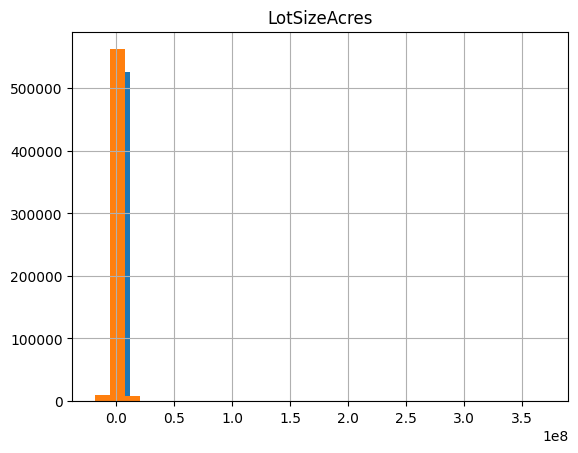

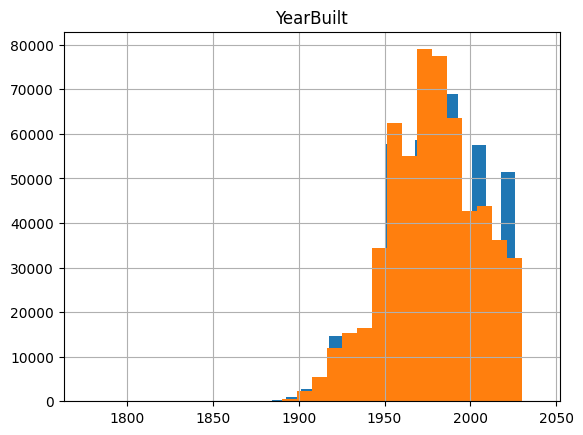

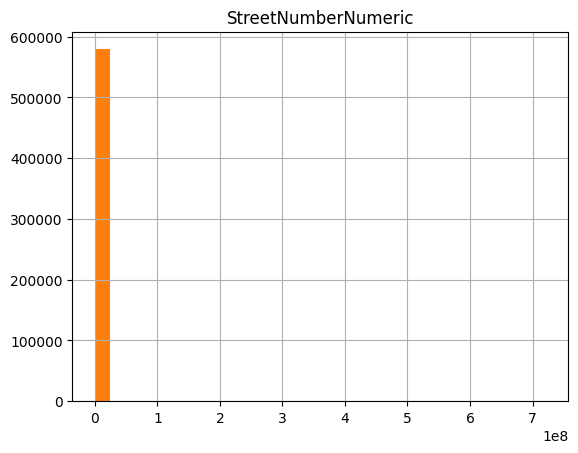

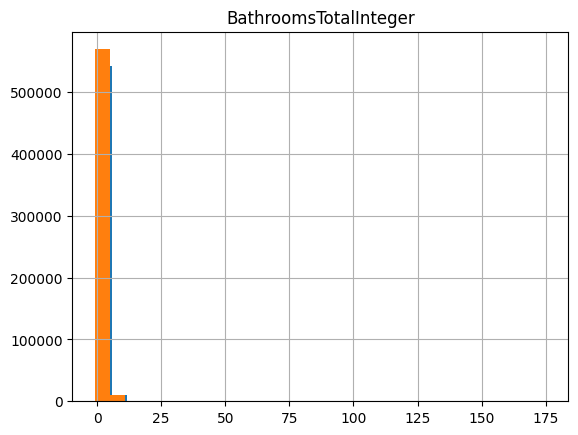

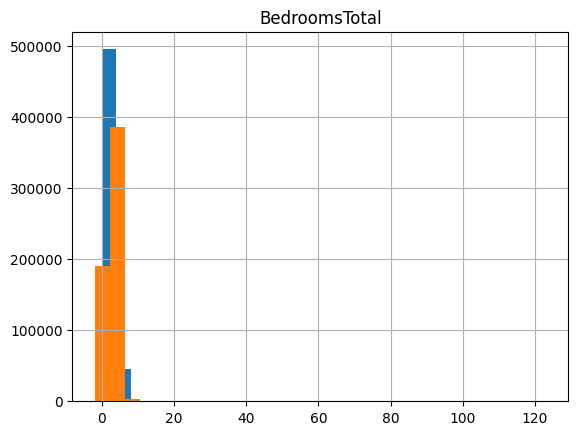

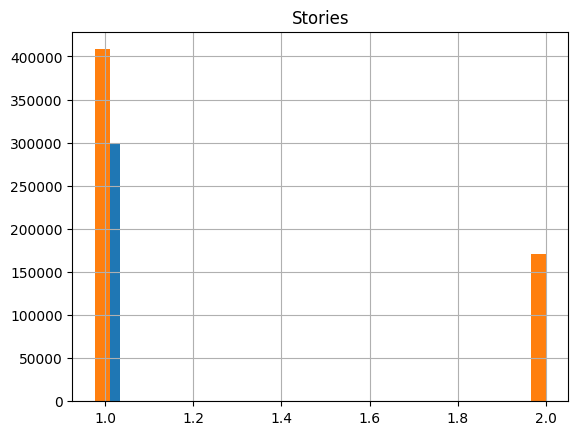

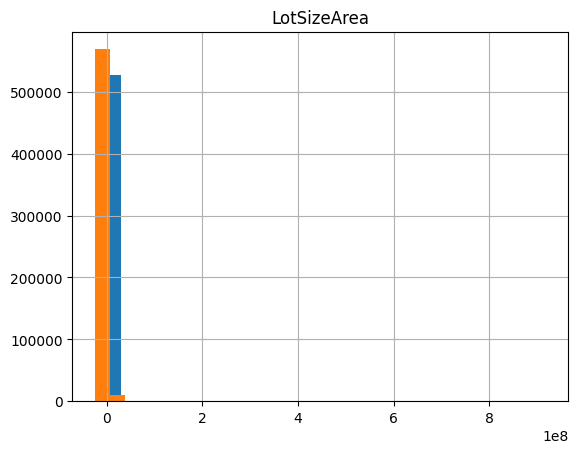

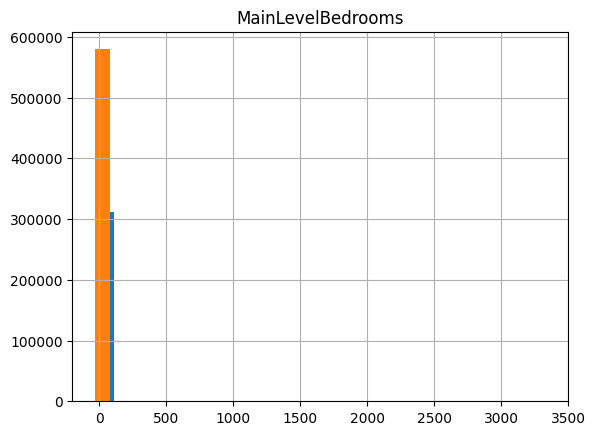

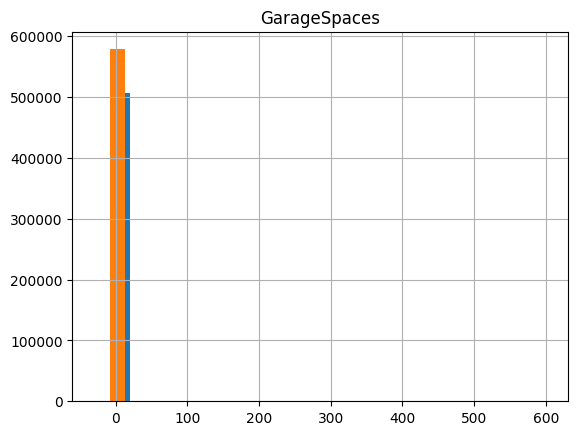

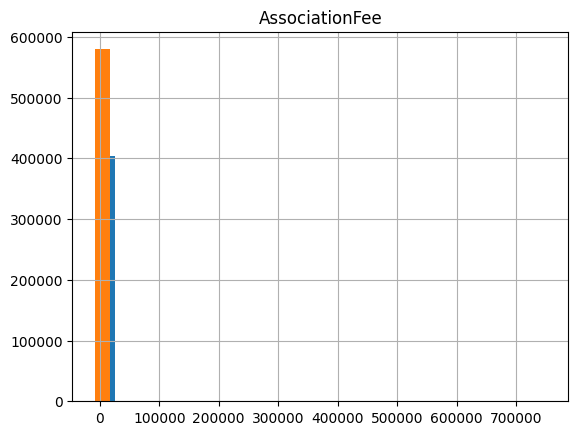

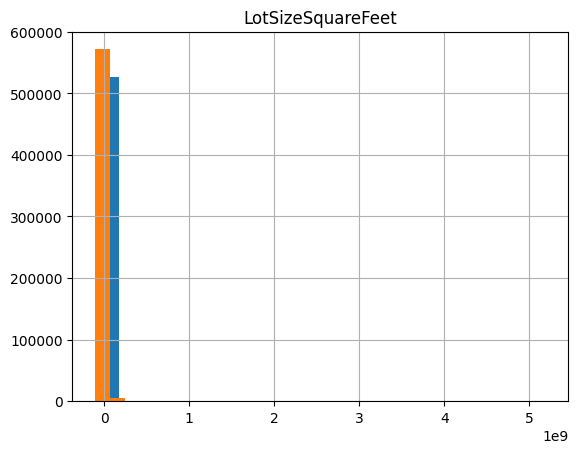

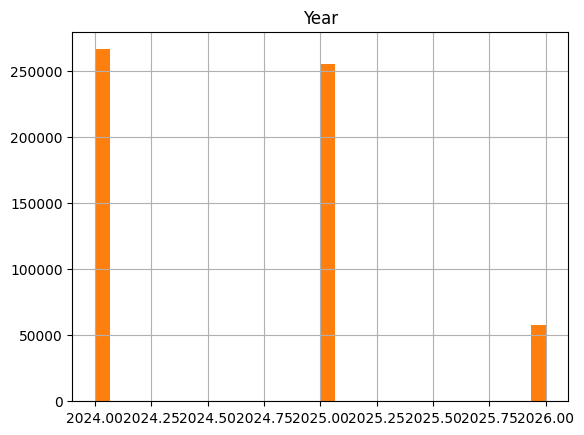

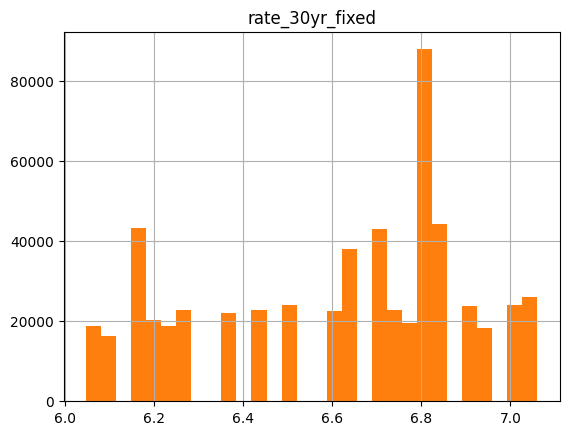

In [152]:
for col in continuous_columns:
    plt.figure()
    df_sold_cleaned[col].dropna().hist(bins=30)
    df_imputed[col].hist(bins=30)
    plt.title(col)
    plt.show()

In [153]:
for col in reduced_categorical_columns:
    print(f"\nColumn: {col}")
    print("Before:")
    print(df_sold_cleaned[col].value_counts(normalize=True, dropna=True))
    print("After:")
    print(df_imputed[col].value_counts(normalize=True))


Column: BuyerAgentAOR
Before:
BuyerAgentAOR
OrangeCounty                           0.099423
PacificWest                            0.067362
BeverlyHillsGreaterLa                  0.066614
Southland                              0.064447
SanDiego                               0.061887
                                         ...   
MariposaCounty                         0.000548
Socalmls                               0.000014
MRMLS                                  0.000004
SandicorMls                            0.000004
TuolumneCountyAssociationOfRealtors    0.000002
Name: proportion, Length: 63, dtype: float64
After:
BuyerAgentAOR
OrangeCounty             0.087412
SanDiego                 0.062104
PacificWest              0.059224
BeverlyHillsGreaterLa    0.058566
Southland                0.056661
                           ...   
Inglewood                0.000561
MariposaCounty           0.000490
SandicorMls              0.000200
Socalmls                 0.000012
MRMLS                

In [154]:
df_sold_cleaned.isna().sum()

BuyerAgentAOR                70005
ListAgentAOR                 66645
Flooring                    238608
ViewYN                       56801
PoolPrivateYN                67059
OriginalListPrice                0
ListingKey                       0
ListAgentEmail                   0
CloseDate                        0
ClosePrice                       0
ListAgentFirstName               0
ListAgentLastName                0
Latitude                     17127
Longitude                    16968
UnparsedAddress                  0
PropertyType                     0
LivingArea                   39648
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
BuyerOfficeName               6566
ListAgentFullName                0
BuyerAgentMlsId                  0
BuyerAgentFirstName              0
BuyerAgentLastName               0
ListingKeyNumeric                0
MLSAreaMajor                 63417
CountyOrParish                   0
MlsStatus           

In [155]:
continuous_columns

Index(['OriginalListPrice', 'ListingKey', 'ClosePrice', 'Latitude',
       'Longitude', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListingKeyNumeric', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt',
       'StreetNumberNumeric', 'BathroomsTotalInteger', 'BedroomsTotal',
       'Stories', 'LotSizeArea', 'MainLevelBedrooms', 'GarageSpaces',
       'AssociationFee', 'LotSizeSquareFeet', 'Year', 'rate_30yr_fixed'],
      dtype='str')

In [159]:
col = 'BedroomsTotal' # pick a column
mask = df_sold_cleaned[col].isna()

print(df_imputed.loc[mask, col].head(10))

1     1.448959
2     0.705419
3     0.240217
4     1.211902
8     1.665578
10   -0.029419
12    5.783618
13    6.423395
15    1.020619
16    1.812538
Name: BedroomsTotal, dtype: float64


In [160]:
df_sold_cleaned[df_sold_cleaned['BedroomsTotal'] < 0]

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed


In [164]:
df_imputed[df_imputed['BedroomsTotal'] < 0].shape

(38, 59)

In [123]:
print("Before correlation:")
print(df_sold_cleaned.corr(numeric_only=True))

print("After correlation:")
print(df_imputed.corr(numeric_only=True))

Before correlation:
                       OriginalListPrice  ListingKey  ClosePrice  Latitude  \
OriginalListPrice               1.000000    0.000130    0.050775  0.011807   
ListingKey                      0.000130    1.000000   -0.001668  0.002102   
ClosePrice                      0.050775   -0.001668    1.000000  0.006726   
Latitude                        0.011807    0.002102    0.006726  1.000000   
Longitude                      -0.015510   -0.013164   -0.013486 -0.539795   
LivingArea                     -0.000105   -0.001315   -0.000124  0.003006   
ListPrice                       0.225317   -0.012390    0.226074  0.029842   
DaysOnMarket                    0.004702   -0.274650   -0.002311  0.023607   
ListingKeyNumeric               0.000130    1.000000   -0.001668  0.002102   
ParkingTotal                   -0.000111   -0.001563   -0.000150 -0.000658   
LotSizeAcres                   -0.000212   -0.001509   -0.000243 -0.000895   
YearBuilt                      -0.003512   -

In [166]:
num_df = df_sold_cleaned.select_dtypes(include=['int64', 'float64'])
num_df.isna().sum().sum()

np.int64(966003)

In [167]:
num_df_imputed = df_imputed.select_dtypes(include=['int64', 'float64'])
num_df_imputed.isna().sum().sum()

np.int64(0)

All the original 966003 numerical values were imputed. 

In [168]:
cat_df = df_sold_cleaned.select_dtypes(include=['object'])
cat_df.isna().sum().sum()

C:\Users\mayab\AppData\Local\Temp\ipykernel_32972\1813330957.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df = df_sold_cleaned.select_dtypes(include=['object'])


np.int64(1566543)

In [169]:
cat_df_imputed = df_imputed.select_dtypes(include=['object'])
cat_df_imputed.isna().sum().sum()

C:\Users\mayab\AppData\Local\Temp\ipykernel_32972\22488813.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df_imputed = df_imputed.select_dtypes(include=['object'])


np.int64(887081)

From 1566543 original categorical values to 887081.

In [170]:
df_imputed.isna().sum()

BuyerAgentAOR                    0
ListAgentAOR                     0
Flooring                    238608
ViewYN                           0
PoolPrivateYN                    0
OriginalListPrice                0
ListingKey                       0
ListAgentEmail                   0
CloseDate                        0
ClosePrice                       0
ListAgentFirstName               0
ListAgentLastName                0
Latitude                         0
Longitude                        0
UnparsedAddress                  0
PropertyType                     0
LivingArea                       0
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
BuyerOfficeName               6566
ListAgentFullName                0
BuyerAgentMlsId                  0
BuyerAgentFirstName              0
BuyerAgentLastName               0
ListingKeyNumeric                0
MLSAreaMajor                 63417
CountyOrParish                   0
MlsStatus           

In [171]:
cat_columns = ['Flooring', 'BuyerOfficeName', 'MLSAreaMajor', 'SubdivisionName', 'PurchaseContractDate', 'HighSchoolDistrict']

In [172]:
cat_df_imputed[cat_columns].nunique()

Flooring                  341
BuyerOfficeName         23982
MLSAreaMajor             1124
SubdivisionName         19585
PurchaseContractDate     1223
HighSchoolDistrict        447
dtype: int64

--------------------------

In [ ]:
#df_imputed.to_csv("../data/Sold/imputed_sold_data.csv", index=False)

In [174]:
df_imputed_sold = pd.read_csv("../data/Sold/imputed_sold_data.csv")
df_imputed_sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,2.226584,False,1.000000,Other,94401,6472.000000,1.020867e+08,2024,2024-01,6.6425
1,HighDesert,HighDesert,NaN,True,False,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,0.092065,False,125.457608,NaN,92394,-21.259968,5.232000e+04,2024,2024-01,6.6425
2,OrangeCounty,OrangeCounty,NaN,True,False,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,1.046258,False,4.301166,NaN,93240,10.756271,2.173640e+05,2024,2024-01,6.6425
3,InlandValleys,InlandValleys,NaN,True,False,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,0.974562,False,6.356953,NaN,92308,215.135641,2.178000e+05,2024,2024-01,6.6425
4,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,True,False,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,1.085406,False,1.124679,NaN,93544,0.000000,1.088830e+05,2024,2024-01,6.6425


In [175]:
df_imputed_sold.isna().sum()

BuyerAgentAOR                    0
ListAgentAOR                     0
Flooring                    238608
ViewYN                           0
PoolPrivateYN                    0
OriginalListPrice                0
ListingKey                       0
ListAgentEmail                2537
CloseDate                        0
ClosePrice                       0
ListAgentFirstName               0
ListAgentLastName                0
Latitude                         0
Longitude                        0
UnparsedAddress                  0
PropertyType                     0
LivingArea                       0
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
BuyerOfficeName               6566
ListAgentFullName                0
BuyerAgentMlsId                  0
BuyerAgentFirstName              0
BuyerAgentLastName               0
ListingKeyNumeric                0
MLSAreaMajor                 63417
CountyOrParish                   0
MlsStatus           

In [176]:
# Create a reference mapping of Names -> Emails
# Drop any rows that have missing emails so the map is 'clean'
email_lookup = df_imputed_sold.dropna(subset=['ListAgentEmail']).drop_duplicates(['ListAgentFirstName', 'ListAgentLastName'])

# Set the names as the index to make the 'lookup' possible
email_lookup = email_lookup.set_index(['ListAgentFirstName', 'ListAgentLastName'])['ListAgentEmail']

# Create a function to apply the logic
def fill_missing_emails(row):
    # Only try to fill if the current email is missing
    if pd.isna(row['ListAgentEmail']):
        # Look up the name in our reference map
        return email_lookup.get((row['ListAgentFirstName'], row['ListAgentLastName']), "None")
    return row['ListAgentEmail']

# Apply it to the dataframe
df_imputed_sold['ListAgentEmail'] = df_imputed_sold.apply(fill_missing_emails, axis=1)

In [177]:
df_imputed_sold['ListAgentEmail'].isna().sum()

np.int64(0)

In [178]:
(df_imputed_sold['ListAgentEmail'] == 'None').sum()

np.int64(2537)

From the code above, I noticed that there are no missing values for list agent's first and last names, so to determine their emails, I tried to look up any matches by full name to get the list agent's emails for the rows that are missing them. If there are no matches, those emails will be preserved by having a value of "None" (i.e. no email provided).

In [179]:
df_imputed_sold.isna().sum()

BuyerAgentAOR                    0
ListAgentAOR                     0
Flooring                    238608
ViewYN                           0
PoolPrivateYN                    0
OriginalListPrice                0
ListingKey                       0
ListAgentEmail                   0
CloseDate                        0
ClosePrice                       0
ListAgentFirstName               0
ListAgentLastName                0
Latitude                         0
Longitude                        0
UnparsedAddress                  0
PropertyType                     0
LivingArea                       0
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
BuyerOfficeName               6566
ListAgentFullName                0
BuyerAgentMlsId                  0
BuyerAgentFirstName              0
BuyerAgentLastName               0
ListingKeyNumeric                0
MLSAreaMajor                 63417
CountyOrParish                   0
MlsStatus           

### **NEXT STEPS (For the rest of Week 3)**

- Handle the other missing values for the categorical variables
- Conduct the missing values and outlier cleaning for sold_transactions

#### **Outlier Cleaning**

In [ ]:
df_listings_clean.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'ClosePrice',
       'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude',
       'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice',
       'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1',
       'MlsStatus', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'DaysOnMarket.1', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'Longitude.1', 'PurchaseContractDate',
       'ListingContractDate', 'Latitude.1', 'ListPrice.1', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'ListAgentLastName.1',
       'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'PostalCode', 'Associatio

In [ ]:
neg_counts = (df_listings_clean.select_dtypes(include='number') < 0).sum()

In [ ]:
neg_counts[neg_counts > 0]

Latitude               7
Longitude         742263
DaysOnMarket          37
ParkingTotal         177
DaysOnMarket.1        37
Longitude.1       742263
Latitude.1             7
dtype: int64

In [ ]:
neg_DaysOnMarket = df_listings_clean[df_listings_clean['DaysOnMarket'] < 0]
neg_DaysOnMarket.head()

,OriginalListPrice,ListingKey,ListAgentEmail,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,Year,year_month,rate_30yr_fixed
223,799000.0,1063549350,ainsleyhughes@kw.com,799000.0,Ainsley,Hughes,34.425577,-119.291855,11905 Silver Spur Street,Residential,...,NaN,2.0,NaN,93023,59.0,5885.0,11905 Silver Spur Street,2024,2024-01,6.6425
228,899000.0,1063528331,absea@comcast.net,810000.0,A.B.,Priceman DRE 0126...,39.383806,-123.789254,31530 Emerald Drive,Residential,...,False,2.0,NaN,95437,NaN,34848.0,31530 Emerald Drive,2024,2024-01,6.6425
752,11500.0,1061271257,teresa.fuller@compass.com,10500.0,Teresa,Fuller,34.081125,-118.363403,536 N Edinburgh Avenue,ResidentialLease,...,NaN,0.0,NaN,90048,0.0,6612.0,536 N Edinburgh Avenue,2024,2024-01,6.6425
1119,1599000.0,1060153479,robert@anppros.com,1625000.0,Robert,Perez,34.244449,-118.265167,3929 El Moreno Street,Residential,...,NaN,2.0,NaN,91214,NaN,5249.0,3929 El Moreno Street,2024,2024-01,6.6425
4167,469999.0,1059512539,khoren9@yahoo.com,NaN,Khoren,Barutyan,34.201700,-118.460053,15015 Sherman Way 103,Residential,...,False,2.0,Los Angeles Unified,91405,390.0,15574.0,15015 Sherman Way 103,2024,2024-01,6.6425


In [ ]:
rows_DaysOnMarket = neg_DaysOnMarket['DaysOnMarket']
rows_DaysOnMarket.head()

223    -48
228    -58
752    -16
1119    -1
4167   -33
Name: DaysOnMarket, dtype: int64

There are negative values for DaysOnMarket, to which I have decided to remove those values. 

In [ ]:
neg_ParkingTotal = df_listings_clean[df_listings_clean['ParkingTotal'] < 0]
neg_ParkingTotal.head()

,OriginalListPrice,ListingKey,ListAgentEmail,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,Year,year_month,rate_30yr_fixed
8376,1100000.0,1058691297,amarprop@aol.com,1120000.0,Lino,Amarante,NaN,NaN,Eastwood Court,ResidentialIncome,...,NaN,1.0,San Jose Unified,95116,NaN,5663.0,Eastwood Court,2024,2024-01,6.6425
8443,2300000.0,1058688466,mabroukhamza093@gmail.com,NaN,Hamza,Mabrouk,NaN,NaN,725 Hyde Street,CommercialSale,...,NaN,NaN,San Francisco Unified,94109,0.0,1650.0,725 Hyde Street,2024,2024-01,6.6425
12223,1258000.0,1058416008,trisha@trishamotter.com,1600000.0,Trisha,Motter,NaN,NaN,7385 Forsum Road,Residential,...,False,2.0,Other,95138,NaN,5227.0,7385 Forsum Road,2024,2024-01,6.6425
26306,1588888.0,1054056032,maryoproperties@yahoo.com,1550000.0,Mary,O'neill,NaN,NaN,2965 Calle De Las Estrella,Residential,...,False,2.0,Other,95148,120.0,3920.0,2965 Calle De Las Estrella,2024,2024-01,6.6425
30751,1599000.0,1061806243,kroyer.re@gmail.com,1620000.0,Kathy,Royer,NaN,NaN,6088 Pietz Court,Residential,...,False,2.0,San Jose Unified,95123,NaN,6098.0,6088 Pietz Court,2024,2024-02,6.7760


In [ ]:
rows_ParkingTotal = neg_ParkingTotal['ParkingTotal']
rows_ParkingTotal.head()

8376      -2.0
8443      -5.0
12223     -3.0
26306     -1.0
30751   -139.0
Name: ParkingTotal, dtype: float64

In [ ]:
non_neg = (df_listings_clean['DaysOnMarket'] >= 0) & (df_listings_clean['ParkingTotal'] >= 0) & (df_listings_clean['DaysOnMarket.1'] >= 0)

In [ ]:
listings_clean = df_listings_clean[non_neg].copy()

In [ ]:
listings_clean.shape

(801183, 57)

In [ ]:
rows_dropped = len(df_listings_clean) - len(listings_clean)
rows_dropped

52571

In [ ]:
neg_counts = (listings_clean.select_dtypes(include='number') < 0).sum()

In [90]:
neg_counts[neg_counts > 0]

Latitude            4
Longitude      694719
Longitude.1    694719
Latitude.1          4
dtype: int64

##### *Sold*

In [28]:
missing_sold_counts = df_sold.isnull().sum()
missing_sold_counts

BuyerAgentAOR       71507
ListAgentAOR        68046
Flooring           243651
ViewYN              59190
WaterfrontYN       590793
                    ...  
latfilled          495322
lonfilled          495322
Year                    0
year_month              0
rate_30yr_fixed         0
Length: 87, dtype: int64

In [29]:
missing_sold_percent = (df_sold.isnull().mean()) * 100
missing_sold_percent

BuyerAgentAOR      12.096969
ListAgentAOR       11.511466
Flooring           41.218883
ViewYN             10.013280
WaterfrontYN       99.945527
                     ...    
latfilled          83.794524
lonfilled          83.794524
Year                0.000000
year_month          0.000000
rate_30yr_fixed     0.000000
Length: 87, dtype: float64

In [30]:
missing_summary = pd.DataFrame({
    "missing_sold_counts": missing_sold_counts,
    "missing_sold_percent": missing_sold_percent
})

In [31]:
missing_sold_summary = missing_summary.sort_values(by="missing_sold_percent", ascending=False)
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                 100.0
AboveGradeFinishedArea                     591115                 100.0
MiddleOrJuniorSchoolDistrict               591115                 100.0
ElementarySchoolDistrict                   591115                 100.0
FireplacesTotal                            591115                 100.0
...                                           ...                   ...
MlsStatus                                       0                   0.0
StateOrProvince                                 0                   0.0
Year                                            0                   0.0
year_month                                      0                   0.0
rate_30yr_fixed                                 0                   0.0

[87 rows x 2 columns]


In [32]:
missing_sold_summary = missing_sold_summary[missing_sold_summary["missing_sold_counts"] > 0]
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115            100.000000
AboveGradeFinishedArea                     591115            100.000000
MiddleOrJuniorSchoolDistrict               591115            100.000000
ElementarySchoolDistrict                   591115            100.000000
FireplacesTotal                            591115            100.000000
...                                           ...                   ...
PostalCode                                    165              0.027913
ListAgentFullName                             161              0.027237
ListingContractDate                            83              0.014041
ListAgentLastName                              61              0.010319
ClosePrice                                      7              0.001184

[74 rows x 2 columns]


In [33]:
missing_sold_summary["missing_sold_percent"] = missing_sold_summary["missing_sold_percent"].round(2)
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                100.00
AboveGradeFinishedArea                     591115                100.00
MiddleOrJuniorSchoolDistrict               591115                100.00
ElementarySchoolDistrict                   591115                100.00
FireplacesTotal                            591115                100.00
...                                           ...                   ...
PostalCode                                    165                  0.03
ListAgentFullName                             161                  0.03
ListingContractDate                            83                  0.01
ListAgentLastName                              61                  0.01
ClosePrice                                      7                  0.00

[74 rows x 2 columns]


In [34]:
missing_above_90 = missing_sold_summary[missing_sold_summary['missing_sold_percent'] > 90]
print(missing_above_90)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                100.00
AboveGradeFinishedArea                     591115                100.00
MiddleOrJuniorSchoolDistrict               591115                100.00
ElementarySchoolDistrict                   591115                100.00
FireplacesTotal                            591115                100.00
WaterfrontYN                               590793                 99.95
TaxYear                                    590748                 99.94
BusinessType                               589483                 99.72
TaxAnnualAmount                            588608                 99.58
BelowGradeFinishedArea                     588525                 99.56
BasementYN                                 581377                 98.35
BuilderName                                568536                 96.18
LotSizeDimensions                          560102               

In [35]:
missing_above_70 = missing_sold_summary[missing_sold_summary['missing_sold_percent'] > 70]
print(missing_above_70)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                100.00
AboveGradeFinishedArea                     591115                100.00
MiddleOrJuniorSchoolDistrict               591115                100.00
ElementarySchoolDistrict                   591115                100.00
FireplacesTotal                            591115                100.00
WaterfrontYN                               590793                 99.95
TaxYear                                    590748                 99.94
BusinessType                               589483                 99.72
TaxAnnualAmount                            588608                 99.58
BelowGradeFinishedArea                     588525                 99.56
BasementYN                                 581377                 98.35
BuilderName                                568536                 96.18
LotSizeDimensions                          560102               

In [36]:
missing_above_70

,missing_sold_counts,missing_sold_percent
CoveredSpaces,591115,100.00
AboveGradeFinishedArea,591115,100.00
MiddleOrJuniorSchoolDistrict,591115,100.00
ElementarySchoolDistrict,591115,100.00
FireplacesTotal,591115,100.00
WaterfrontYN,590793,99.95
TaxYear,590748,99.94
BusinessType,589483,99.72
TaxAnnualAmount,588608,99.58
BelowGradeFinishedArea,588525,99.56


In [37]:
df_sold_clean = df_sold.drop(columns=['MiddleOrJuniorSchoolDistrict', 'ElementarySchoolDistrict', 'CoveredSpaces', 
                                      'FireplacesTotal', 'AboveGradeFinishedArea', 'WaterfrontYN',
                                      'TaxYear', 'BusinessType', 'TaxAnnualAmount', 'BelowGradeFinishedArea',
                                      'BasementYN', 'BuilderName', 'LotSizeDimensions', 'CoBuyerAgentFirstName',
                                      'OriginatingSystemName', 'OriginatingSystemSubName', 'ElementarySchool', 
                                      'MiddleOrJuniorSchool', 'BuyerAgencyCompensationType', 'BuyerAgencyCompensation', 
                                      'BuildingAreaTotal', 'HighSchool', 'latfilled', 'lonfilled', 'CoListAgentFirstName', 
                                      'CoListAgentLastName', 'CoListOfficeName', 'AssociationFeeFrequency'])

In [38]:
df_sold_clean.shape

(591115, 59)

#### **Outlier Cleaning**